## Практическая работа №1

### Выполнил: Зацепин Максим Андреевич, студент группы М092602(77)

### Задание

- Найти данные для построения матрицы корреляции (ВАЖНО чтобы данные были с ежедневным учётом (год, месяц, день) или любые другие многоуровневые данные, для мультииндекса(ДАННЫЕ ПО ПОГОДЕ НЕ БРАТЬ)
- Сформулировать гипотезу (Обязательно прописать ее в файле, также вставить ссылку на данные)
- Поработать с мультииндексом (как в лекции)
- Построить матрицу корреляции и точечный график (график рассеивания)
- Сделать соответствующий вывод (подтвердилась ли ваша гипотеза или нет)

### Датасет - [https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset](https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset)

Содержит суточные данные о системе городского проката велосипедов Capital Bikeshare (Вашингтон, США) за 2011–2012 годы (всего 731 запись)

Ключевые анализируемые показатели:
- `casual` — количество поездок, совершенных разовыми (незарегистрированными) клиентами
- `registered` — количество поездок, совершенных постоянными подписчиками сервиса
- `cnt` — суммарное количество арендованных велосипедов за день (cnt = casual + registered)
- `hum` — нормированная влажность воздуха (значения приведены к диапазону [0, 1])

Производные показатели, рассчитанные в ходе работы:
- `User_Diff` — показатель абсолютного преобладания зарегестрированных
$$ User\_Diff = registered - casual$$
- `User_Ratio`  — доля зарегистрированных пользователей в общем объеме
$$ User\_Ratio = \frac{registered}{cnt}$$

Краткая характеристика данных:
- Диапазон общего дневного спроса (cnt): от 22 до 8714 поездок (медиана — 4548)
- Диапазон разницы пользователей (User_Diff): от -102 до 6159 (медиана — 2789)
- Динамика роста: С 2011 по 2012 год среднесуточный объем поездок вырос на 64% 
  (с 3405.76 до 5599.93), при этом показатель User_Diff увеличился с 2050.96 до 3562.97

Гипотеза: существует сильная прямая корреляция между количеством зарегистрированных пользователей (registered) и общим объемом поездок (cnt), а также умеренная положительная корреляция между разницей категорий пользователей (registered - casual) и суммарным спросом (cnt), при этом разница категорий не демонстрирует существенной линейной связи с нормированной влажностью воздуха (hum)

In [158]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("day.csv") 

# Первичная обработка данных для мультииндекса
df['dteday'] = pd.to_datetime(df['dteday'])
df['Year'] = df['dteday'].dt.year
df['Month'] = df['dteday'].dt.month
df['Day'] = df['dteday'].dt.day

# Формирование необходимых для анализа параметров
df['User_Diff'] = df['registered'] - df['casual'] 
df['User_Ratio'] = df['registered'] / df['cnt']

df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,...,hum,windspeed,casual,registered,cnt,Year,Month,Day,User_Diff,User_Ratio
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,...,0.805833,0.160446,331,654,985,2011,1,1,323,0.663959
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,...,0.696087,0.248539,131,670,801,2011,1,2,539,0.836454
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,...,0.437273,0.248309,120,1229,1349,2011,1,3,1109,0.911045
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,...,0.590435,0.160296,108,1454,1562,2011,1,4,1346,0.930858
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,...,0.436957,0.186900,82,1518,1600,2011,1,5,1436,0.948750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,...,0.652917,0.350133,247,1867,2114,2012,12,27,1620,0.883160
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,...,0.590000,0.155471,644,2451,3095,2012,12,28,1807,0.791922
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,...,0.752917,0.124383,159,1182,1341,2012,12,29,1023,0.881432
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,...,0.483333,0.350754,364,1432,1796,2012,12,30,1068,0.797327


In [159]:
# Мультииндекс
multi = df.set_index(['Year', 'Month', 'Day'])
multi


instant     dteday  season  yr  mnth  holiday  weekday  \
Year Month Day                                                           
2011 1     1          1 2011-01-01       1   0     1        0        6   
           2          2 2011-01-02       1   0     1        0        0   
           3          3 2011-01-03       1   0     1        0        1   
           4          4 2011-01-04       1   0     1        0        2   
           5          5 2011-01-05       1   0     1        0        3   
...                 ...        ...     ...  ..   ...      ...      ...   
2012 12    27       727 2012-12-27       1   1    12        0        4   
           28       728 2012-12-28       1   1    12        0        5   
           29       729 2012-12-29       1   1    12        0        6   
           30       730 2012-12-30       1   1    12        0        0   
           31       731 2012-12-31       1   1    12        0        1   

                workingday  weathersit      temp     atemp       hum  \
Year Month Day                                                         
2011 1     1             0           2  0.344167  0.363625  0.805833   
           2             0           2  0.363478  0.353739  0.696087   
           3             1           1  0.196364  0.189405  0.437273   
           4             1           1  0.200000  0.212122  0.590435   
           5             1           1  0.226957  0.229270  0.436957   
...                    ...         ...       ...       ...       ...   
2012 12    27            1           2  0.254167  0.226642  0.652917   
           28            1           2  0.253333  0.255046  0.590000   
           29            0           2  0.253333  0.242400  0.752917   
           30            0           1  0.255833  0.231700  0.483333   
           31            1           2  0.215833  0.223487  0.577500   

                windspeed  casual  registered   cnt  User_Diff  User_Ratio  
Year Month Day                                                              
2011 1     1     0.160446     331         654   985        323    0.663959  
           2     0.248539     131         670   801        539    0.836454  
           3     0.248309     120        1229  1349       1109    0.911045  
           4     0.160296     108        1454  1562       1346    0.930858  
           5     0.186900      82        1518  1600       1436    0.948750  
...                   ...     ...         ...   ...        ...         ...  
2012 12    27    0.350133     247        1867  2114       1620    0.883160  
           28    0.155471     644        2451  3095       1807    0.791922  
           29    0.124383     159        1182  1341       1023    0.881432  
           30    0.350754     364        1432  1796       1068    0.797327  
           31    0.154846     439        2290  2729       1851    0.839135  

[731 rows x 18 columns]

In [160]:
# Срез за Ноябрь 2012"
multi.loc[(2012, 11)].head(10)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,User_Diff,User_Ratio
Day,,,,,,,,,,,,,,,,,,
1,671,2012-11-01,4,1,11,0,4,1,2,0.365833,0.369942,0.581667,0.157346,466,5520,5986,5054,0.922152
2,672,2012-11-02,4,1,11,0,5,1,1,0.355000,0.356042,0.522083,0.266175,618,5229,5847,4611,0.894305
3,673,2012-11-03,4,1,11,0,6,0,2,0.343333,0.323846,0.491250,0.270529,1029,4109,5138,3080,0.799728
4,674,2012-11-04,4,1,11,0,0,0,1,0.325833,0.329538,0.532917,0.179108,1201,3906,5107,2705,0.764833
5,675,2012-11-05,4,1,11,0,1,1,1,0.319167,0.308075,0.494167,0.236325,378,4881,5259,4503,0.928123
6,676,2012-11-06,4,1,11,0,2,1,1,0.280833,0.281567,0.567083,0.173513,466,5220,5686,4754,0.918044
7,677,2012-11-07,4,1,11,0,3,1,2,0.295833,0.274621,0.547500,0.304108,326,4709,5035,4383,0.935253
8,678,2012-11-08,4,1,11,0,4,1,1,0.352174,0.341891,0.333478,0.347835,340,4975,5315,4635,0.936030
9,679,2012-11-09,4,1,11,0,5,1,1,0.361667,0.355413,0.540833,0.214558,709,5283,5992,4574,0.881676


In [161]:
cols = ['casual', 'registered', 'cnt', 'User_Diff', 'hum']
corr_m = df[cols].corr()

print("Корреляция:")
print(corr_m)

Корреляция:
              casual  registered       cnt  User_Diff       hum
casual      1.000000    0.395282  0.672804  -0.048701 -0.077008
registered  0.395282    1.000000  0.945517   0.898219 -0.091089
cnt         0.672804    0.945517  1.000000   0.706176 -0.100659
User_Diff  -0.048701    0.898219  0.706176   1.000000 -0.062197
hum        -0.077008   -0.091089 -0.100659  -0.062197  1.000000


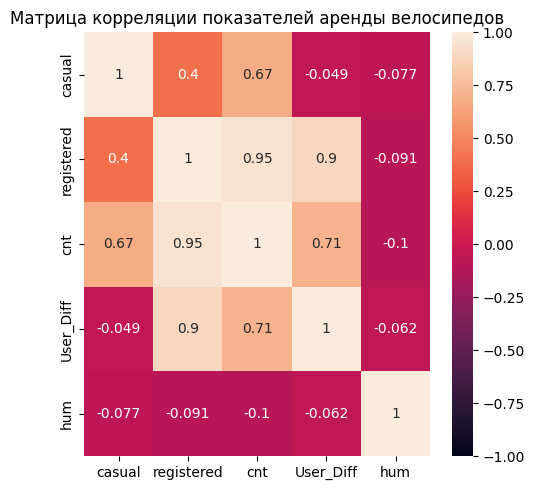

In [162]:
# Визуализация 
plt.figure(figsize=(5, 5))
sns.heatmap(
    corr_m, 
    annot=True, 
    vmin=-1, 
    vmax=1
)
plt.title('Матрица корреляции показателей аренды велосипедов')
plt.tight_layout()
plt.show()

### Анализ:

- Сильная прямая корреляция между `registered` и `cnt` подтвердилась
Коэффициент корреляции = 0.9455, что свидетельствует о практически линейной зависимости, тоесть зарегистрированные пользователи формируют основной объем суточного спроса

- Умеренная положительная корреляция между `User_Diff` и `cnt` подтвердилась
Коэффициент = 0.7062 - в дни с высоким суммарным объемом поездок перевес постоянных клиентов над разовыми существенно увеличивается

- Отсутствие существенной линейной связи `User_Diff` с `hum` подтвердилось
Коэффициент корреляции = -0.062197 (близок к нулю), подтверждая, что нормализованная влажность воздуха практически не влияет на соотношение категорий пользователей

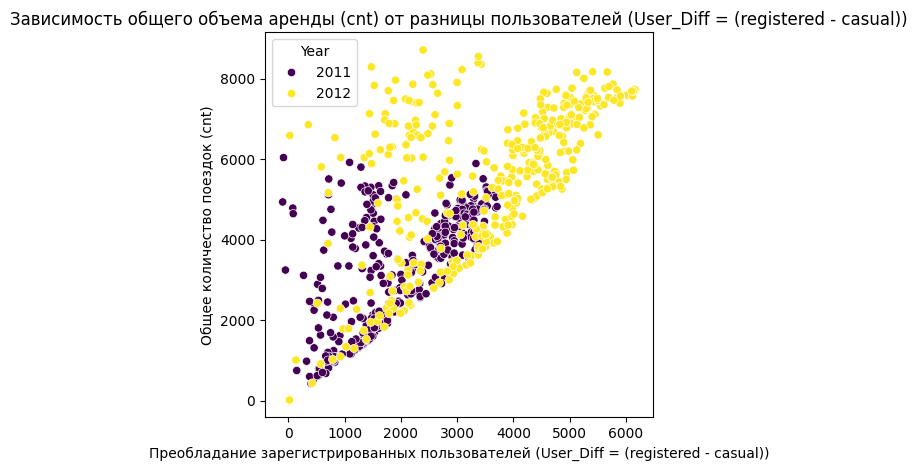

In [163]:
plt.figure(figsize=(5, 5))
sns.scatterplot(
    data=df, 
    palette='viridis',
    x='User_Diff', 
    y='cnt', 
    hue='Year'
)

plt.title('Зависимость общего объема аренды (cnt) от разницы пользователей (User_Diff = (registered - casual))')
plt.xlabel('Преобладание зарегистрированных пользователей (User_Diff = (registered - casual))')
plt.ylabel('Общее количество поездок (cnt)')

plt.show()

### Вывод

- Точечный график визуально и полностью подтверждает выдвинутую гипотезу

- На диаграмме отчетливо прослеживается диагональный тренд: с ростом показателя User_Diff (преобладание постоянных клиентов) пропорционально увеличивается суммарный объем поездок (cnt)

- На графике отчетливо прослеживается четкое двухкластерное разделение данных по годам: в 2011 году (темные точки ) объем поездок находился в пределах до 6000, а показатель User_Diff в редкие дни превышал 3500. В 2012 году (светлые точки) происходит сдвиг в верхний правый угол, где суточная аренда достигает 8714 поездок, а преобладание подписчиков возрастает до 6159